# 02 — Centrality (Course topic L3)

**Semiconductor Supply Chain — Network Analysis**

Who are the real bottlenecks? We compute four centrality measures on the
directed `SUPPLIES` network and cross-read them:

| measure | reads as |
|---|---|
| **degree** (in/out) | direct reach — many suppliers/customers |
| **betweenness** | brokerage — share of supply paths passing through a firm |
| **closeness** | how quickly a firm reaches the rest of the chain |
| **eigenvector / PageRank** | influence — connected *to* important firms |

This is the first direct test of the hypothesis' named hubs (TSMC, ASML,
Shin-Etsu, Air Products, an ARM licensor), now on the expanded ~100-company
network.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import analysis

D = analysis.company_supply_digraph()
U = D.to_undirected(as_view=False)
print(f'{D.number_of_nodes()} companies, {D.number_of_edges()} SUPPLIES edges')

108 companies, 1256 SUPPLIES edges


## 1. Compute centralities

Betweenness/closeness are computed on the directed graph (supply *flow*
direction matters). Eigenvector centrality is run on the undirected view for
numerical stability; PageRank gives the directed analogue.

In [2]:
cent = pd.DataFrame({
    'type': pd.Series(dict(D.nodes(data='type'))),
    'in_degree': pd.Series(dict(D.in_degree())),
    'out_degree': pd.Series(dict(D.out_degree())),
    'betweenness': pd.Series(nx.betweenness_centrality(D, normalized=True)),
    'closeness': pd.Series(nx.closeness_centrality(D)),
    'eigenvector': pd.Series(nx.eigenvector_centrality(U, max_iter=1000)),
    'pagerank': pd.Series(nx.pagerank(D)),
})
cent = cent.round(4).sort_values('betweenness', ascending=False)
cent.head(15)

,type,in_degree,out_degree,betweenness,closeness,eigenvector,pagerank
TSMC,fab,44,17,0.0289,0.4212,0.1594,0.0128
ASML,equipment,3,27,0.0056,0.0280,0.1200,0.0090
Samsung Foundry,fab,39,5,0.0054,0.3677,0.1401,0.0110
Apple,fabless,28,1,0.0041,0.4308,0.0902,0.0708
SK Hynix,IDM,33,5,0.0038,0.3121,0.1308,0.0086
UMC,fab,32,5,0.0035,0.3067,0.1295,0.0088
Samsung Memory,IDM,33,5,0.0031,0.3121,0.1325,0.0086
Tokyo Electron,equipment,3,27,0.0030,0.0280,0.1202,0.0067
Lam Research,equipment,3,27,0.0030,0.0280,0.1202,0.0067
Applied Materials,equipment,3,27,0.0030,0.0280,0.1202,0.0067


## 2. Ranking leaders by each measure

Different measures spotlight different roles — that disagreement is itself the
finding.

In [3]:
leaders = pd.DataFrame({
    m: cent[m].sort_values(ascending=False).head(8).index.tolist()
    for m in ['out_degree', 'in_degree', 'betweenness', 'closeness',
              'eigenvector', 'pagerank']
}, index=[f'#{i}' for i in range(1, 9)])
leaders

,out_degree,in_degree,betweenness,closeness,eigenvector,pagerank
#1,Cadence,TSMC,TSMC,Apple,TSMC,Foxconn
#2,Synopsys,NXP,ASML,NXP,NXP,Apple
#3,Siemens EDA,Intel,Samsung Foundry,TSMC,Texas Instruments,Tesla
#4,ASML,STMicroelectronics,Apple,Intel,Analog Devices,Novatek
#5,KLA,Infineon,SK Hynix,STMicroelectronics,STMicroelectronics,Realtek
#6,Hitachi High-Tech,Renesas,UMC,Infineon,Infineon,HiSilicon
#7,Tokyo Ohka Kogyo,Samsung Foundry,Samsung Memory,Renesas,Renesas,Qualcomm
#8,Air Liquide,Analog Devices,Tokyo Electron,Samsung Foundry,onsemi,NXP


In [4]:
# Where do the hypothesis' named hubs land?
named = ['TSMC', 'ASML', 'Shin-Etsu Chemical', 'Air Products', 'ARM']
ranks = {}
for m in ['betweenness', 'out_degree', 'closeness', 'pagerank']:
    order = cent[m].sort_values(ascending=False)
    ranks[m] = {c: int(order.index.get_loc(c)) + 1 for c in named}
print(f'Rank (1 = top of {len(cent)}) of the hypothesis hubs by measure:')
display(pd.DataFrame(ranks))

Rank (1 = top of 108) of the hypothesis hubs by measure:


,betweenness,out_degree,closeness,pagerank
TSMC,1,39,3,15
ASML,2,4,53,33
Shin-Etsu Chemical,51,9,75,75
Air Products,75,31,77,77
ARM,97,38,101,101


## 3. Visualise — betweenness vs. degree

A firm that is high-betweenness but only moderate-degree is a *structural*
bottleneck: it brokers paths it doesn't dominate by sheer connection count.

saved C:\Users\Max\Desktop\project\reports\figures\02_betweenness_vs_degree.png


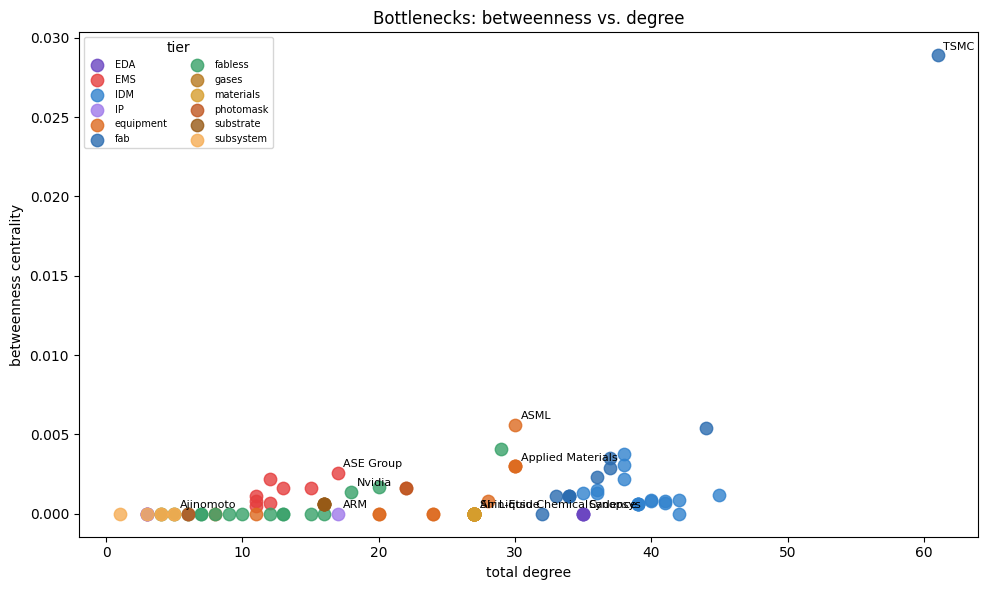

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
for t, sub in cent.groupby('type'):
    ax.scatter(sub['out_degree'] + sub['in_degree'], sub['betweenness'],
               s=80, alpha=0.8, label=t, color=analysis.tier_color(t))
for name in ['TSMC', 'ASML', 'Shin-Etsu Chemical', 'Applied Materials',
             'Air Liquide', 'Synopsys', 'Cadence', 'ARM', 'Ajinomoto',
             'ASE Group', 'Nvidia']:
    if name in cent.index:
        r = cent.loc[name]
        ax.annotate(name, (r['out_degree'] + r['in_degree'], r['betweenness']),
                    fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set(xlabel='total degree', ylabel='betweenness centrality',
       title='Bottlenecks: betweenness vs. degree')
ax.legend(title='tier', fontsize=7, ncol=2)
fig.tight_layout()
out = analysis.FIGURES / '02_betweenness_vs_degree.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print('saved', out)
plt.show()

## 4. Takeaways

- **Out-degree and betweenness top out on the cross-cutting enablers and
  upstream tiers** — EDA (Synopsys, Cadence, Siemens EDA, which every designer
  needs), equipment (ASML, Applied Materials, Lam, Tokyo Electron), and
  materials/gases (Shin-Etsu, Air Liquide). They sell into the whole industry,
  so the shortest supply paths route through them: textbook bottlenecks.
- **TSMC** scores high on in-degree *and* brokerage: it absorbs the entire
  upstream and feeds most fabless designers — the pivot of the network.
- **Single-firm chokepoints** stand out at moderate degree but high criticality
  — Ajinomoto (ABF film), Carl Zeiss SMT (EUV optics), Lasertec (EUV mask
  inspection) — flagged structurally in `03_connectivity`.
- The measures **disagree by design**, but the hypothesis hubs sit near the top
  across measures, supporting their structural importance.

**Next:** `03_connectivity.ipynb` — components, **articulation points** and
bridges: which single firms, if removed, disconnect the graph.